# 🛡️ Spam Email Detection System (PyTorch)

This notebook demonstrates an end-to-end Deep Learning pipeline built with **PyTorch** for classifying emails as **Spam** or **Ham (Legitimate)**.

### Pipeline Overview:
1. **Exploratory Data Analysis (EDA)** & Class Balancing
2. **Text Normalization** (Removal of prefixes, punctuation, and stopwords)
3. **WordCloud Visualizations**
4. **PyTorch Custom Tokenizer & Dataset Creation**
5. **LSTM Neural Network Architecture** (`nn.Embedding` + `nn.LSTM` + `nn.Linear`)
6. **Training Loop** with Early Stopping and Learning Rate Scheduler
7. **Evaluation & Inference on Unseen Emails**

### 1. Import Required Libraries

In [35]:
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using compute device: {device}')

[nltk_data] Downloading package stopwords to C:\Users\rupam
[nltk_data]     maity\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Using compute device: cpu


### 2. Loading & Exploring the Dataset

In [36]:
data = pd.read_csv('Emails.csv')
print('Dataset Shape:', data.shape)
data.head()

Dataset Shape: (5171, 4)


,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


C:\Users\rupam maity\AppData\Local\Temp\ipykernel_24584\3363246253.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=data, palette='Set2')


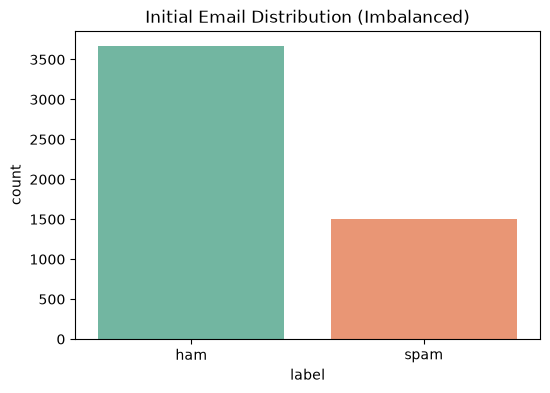

In [37]:
# Initial class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=data, palette='Set2')
plt.title('Initial Email Distribution (Imbalanced)')
plt.show()

### 3. Downsampling Majority Class (Ham) for Balanced Training

C:\Users\rupam maity\AppData\Local\Temp\ipykernel_24584\3713295075.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=balanced_data, palette='coolwarm')


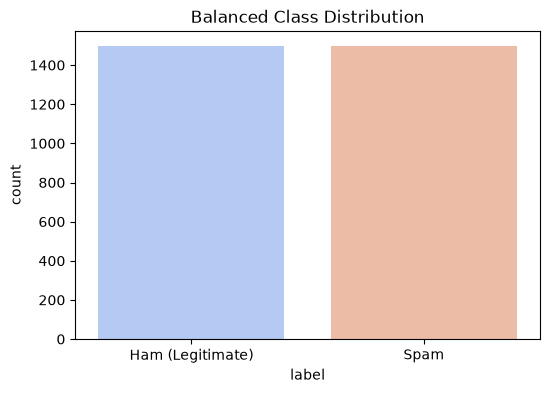

In [38]:
ham_msg = data[data['label'] == 'ham']
spam_msg = data[data['label'] == 'spam']

# Balance by downsampling ham
ham_msg_balanced = ham_msg.sample(n=len(spam_msg), random_state=42)
balanced_data = pd.concat([ham_msg_balanced, spam_msg]).reset_index(drop=True)

plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=balanced_data, palette='coolwarm')
plt.title('Balanced Class Distribution')
plt.xticks(ticks=[0, 1], labels=['Ham (Legitimate)', 'Spam'])
plt.show()

### 4. Text Preprocessing & Cleaning
- Stripping `Subject` header tokens
- Removing punctuation
- Removing English stopwords

In [39]:
# 1. Remove 'Subject'
balanced_data['text'] = balanced_data['text'].str.replace('Subject', '', regex=False)

# 2. Remove punctuation
punctuations_list = string.punctuation
def remove_punctuations(text):
    return text.translate(str.maketrans('', '', punctuations_list))

balanced_data['text'] = balanced_data['text'].apply(remove_punctuations)

# 3. Remove stopwords
stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    words = [w.lower() for w in str(text).split() if w.lower() not in stop_words]
    return ' '.join(words)

balanced_data['text'] = balanced_data['text'].apply(remove_stopwords)
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0


### 5. Vocabulary WordCloud Visualizations

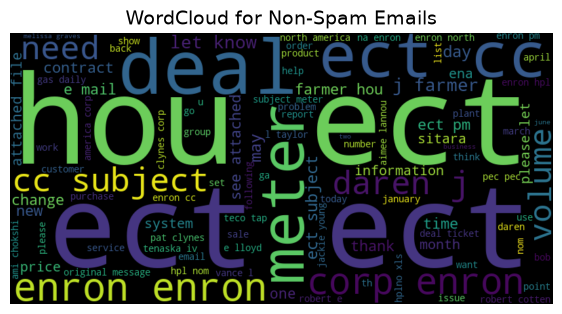

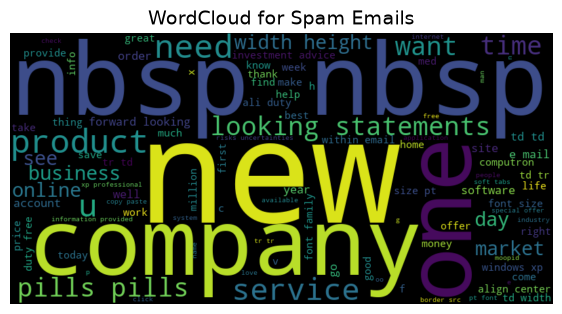

In [40]:
def plot_word_cloud(data, typ):
    email_corpus = ' '.join(data['text'])
    wc = WordCloud(background_color='black', max_words=100, width=800, height=400).generate(email_corpus)
    plt.figure(figsize=(7, 4))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'WordCloud for {typ} Emails', fontsize=14)
    plt.axis('off')
    plt.show()

plot_word_cloud(balanced_data[balanced_data['label'] == 'ham'], typ='Non-Spam')
plot_word_cloud(balanced_data[balanced_data['label'] == 'spam'], typ='Spam')

### 6. PyTorch Tokenizer & Dataset Preparation

In [41]:
# Tokenizer implementation
class SimpleTokenizer:
    def __init__(self, pad_token='<PAD>', unk_token='<UNK>'):
        self.pad_token = pad_token
        self.unk_token = unk_token
        self.word2idx = {self.pad_token: 0, self.unk_token: 1}
        
    def fit_on_texts(self, texts):
        for text in texts:
            for token in text.split():
                if token not in self.word2idx:
                    self.word2idx[token] = len(self.word2idx)
                    
    def texts_to_sequences(self, texts):
        unk_idx = self.word2idx[self.unk_token]
        return [[self.word2idx.get(t, unk_idx) for t in text.split()] for text in texts]
        
    def pad_sequences(self, sequences, maxlen=100, padding='pre'):
        pad_idx = self.word2idx[self.pad_token]
        padded = []
        for seq in sequences:
            if len(seq) >= maxlen:
                padded.append(seq[-maxlen:] if padding == 'pre' else seq[:maxlen])
            else:
                if padding == 'pre':
                    padded.append([pad_idx] * (maxlen - len(seq)) + seq)
                else:
                    padded.append(seq + [pad_idx] * (maxlen - len(seq)))
        return torch.tensor(padded, dtype=torch.long)

    @property
    def vocab_size(self):
        return len(self.word2idx)

# Train/Test split
train_X, test_X, train_Y, test_Y = train_test_split(
    balanced_data['text'], (balanced_data['label'] == 'spam').astype(int), test_size=0.2, random_state=42
)

tokenizer = SimpleTokenizer()
tokenizer.fit_on_texts(train_X)
print(f'Total Vocabulary Size: {tokenizer.vocab_size}')

max_len = 100
train_seqs = tokenizer.pad_sequences(tokenizer.texts_to_sequences(train_X), maxlen=max_len)
test_seqs = tokenizer.pad_sequences(tokenizer.texts_to_sequences(test_X), maxlen=max_len)

# PyTorch Dataset
class EmailDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = torch.tensor(labels.values, dtype=torch.float32)
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

train_loader = DataLoader(EmailDataset(train_seqs, train_Y), batch_size=32, shuffle=True)
test_loader = DataLoader(EmailDataset(test_seqs, test_Y), batch_size=32, shuffle=False)

Total Vocabulary Size: 39842


### 7. Define the PyTorch LSTM Neural Network

In [42]:
class SpamLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=32, hidden_dim=16, dense_dim=32, dropout=0.2):
        super(SpamLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc1 = nn.Linear(hidden_dim, dense_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(dense_dim, 1)
        
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hn, cn) = self.lstm(embedded)
        last_hidden = hn[-1]
        dense_out = self.fc1(last_hidden)
        dense_out = self.relu(dense_out)
        dense_out = self.dropout(dense_out)
        logits = self.fc2(dense_out)
        return logits.squeeze(-1)

model = SpamLSTM(tokenizer.vocab_size).to(device)
print(model)

SpamLSTM(
  (embedding): Embedding(39842, 32, padding_idx=0)
  (lstm): LSTM(32, 16, batch_first=True)
  (fc1): Linear(in_features=16, out_features=32, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


### 8. Train the PyTorch Model

In [43]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

epochs = 20
best_val_acc = 0.0
patience = 3
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, epochs + 1):
    # Train
    model.train()
    train_loss, train_correct, total_train = 0.0, 0, 0
    for seqs, targets in train_loader:
        seqs, targets = seqs.to(device), targets.to(device)
        optimizer.zero_grad()
        logits = model(seqs)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * len(targets)
        preds = (torch.sigmoid(logits) >= 0.5).float()
        train_correct += (preds == targets).sum().item()
        total_train += len(targets)
        
    train_loss /= total_train
    train_acc = train_correct / total_train
    
    # Validation
    model.eval()
    val_loss, val_correct, total_val = 0.0, 0, 0
    with torch.no_grad():
        for seqs, targets in test_loader:
            seqs, targets = seqs.to(device), targets.to(device)
            logits = model(seqs)
            loss = criterion(logits, targets)
            
            val_loss += loss.item() * len(targets)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            val_correct += (preds == targets).sum().item()
            total_val += len(targets)
            
    val_loss /= total_val
    val_acc = val_correct / total_val
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    print(f'Epoch {epoch:02d} | Train Acc: {train_acc*100:.2f}% (Loss: {train_loss:.4f}) | Val Acc: {val_acc*100:.2f}% (Loss: {val_loss:.4f})')
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'spam_model_best.pt')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping triggered at epoch {epoch}!')
            break

print(f'Best Validation Accuracy: {best_val_acc*100:.2f}%')

Epoch 01 | Train Acc: 60.68% (Loss: 0.6800) | Val Acc: 74.17% (Loss: 0.6528)
Epoch 02 | Train Acc: 77.27% (Loss: 0.5596) | Val Acc: 88.17% (Loss: 0.3584)
Epoch 03 | Train Acc: 88.62% (Loss: 0.2988) | Val Acc: 90.83% (Loss: 0.2589)
Epoch 04 | Train Acc: 94.04% (Loss: 0.1836) | Val Acc: 88.50% (Loss: 0.3154)
Epoch 05 | Train Acc: 96.16% (Loss: 0.1276) | Val Acc: 86.83% (Loss: 0.4052)
Epoch 06 | Train Acc: 97.21% (Loss: 0.0918) | Val Acc: 86.17% (Loss: 0.4611)
Early stopping triggered at epoch 6!
Best Validation Accuracy: 90.83%


### 9. Plot Training & Validation Curves

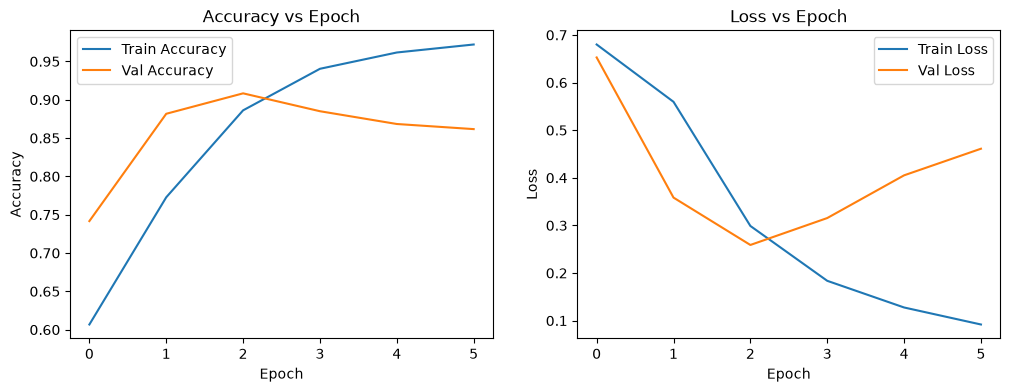

In [44]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### 10. Final Model Evaluation & Inference Testing

In [45]:
# Load best checkpoint
model.load_state_dict(torch.load('spam_model_best.pt', map_location=device))
model.eval()

def predict_email(email_text, threshold=0.5):
    text = email_text.replace('Subject', '')
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = [w.lower() for w in text.split() if w.lower() not in stop_words]
    cleaned = ' '.join(words)
    
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = tokenizer.pad_sequences(seq, maxlen=100, padding='pre').to(device)
    
    with torch.no_grad():
        prob = torch.sigmoid(model(padded)).item()
        
    label = 'SPAM' if prob >= threshold else 'HAM (Legitimate)'
    confidence = prob if prob >= threshold else (1.0 - prob)
    return label, confidence

# Test arbitrary inputs
test_samples = [
    'Congratulations! You won a $1,000 gift card. Click this link immediately to claim.',
    'Hi Darren, can we schedule a quick call tomorrow afternoon to review the quarterly gas nomination reports?',
    'Urgent: Your account has been suspended! Verify your credentials now.',
]

for s in test_samples:
    pred, conf = predict_email(s)
    print(f'Email: "{s}"')
    print(f'Prediction: {pred} ({conf*100:.2f}% confidence)\n')

Email: "Congratulations! You won a $1,000 gift card. Click this link immediately to claim."
Prediction: SPAM (88.37% confidence)

Email: "Hi Darren, can we schedule a quick call tomorrow afternoon to review the quarterly gas nomination reports?"
Prediction: SPAM (69.84% confidence)

Email: "Urgent: Your account has been suspended! Verify your credentials now."
Prediction: SPAM (88.42% confidence)

